# AG-HYPOPT · Trial 06

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Five trials are registered; the campaign has now completed the uninformed (`uniform`) phase and cell 2 reports `phase = trials` (5/5), i.e. candidates now carry expected-improvement (ei) values. **Best = trial_01** (objective 0.1127). All five, with mu travel = `lr_mu*(1 - mu_anneal/2)`:

- **trial_01 (0.1127, best, 0 diverged):** `lr_mu=0.1551`, `mu_anneal=0.4535`, `lr_gamma=0.7990`, `gamma_anneal=0.2968` (travel 0.120). mu rel-RMSE 77.1%; gamma 21.5%.
- **trial_05 (0.1135, 0 diverged):** `lr_mu=0.1056`, `mu_anneal=0.3249`, `lr_gamma=0.4648`, `gamma_anneal=0.4530` (travel 0.088). Tied with trial_01 in objective but with much better mu (rel-RMSE 56.6%) and, crucially, gamma finite on all 8 cells.
- **trial_03 (0.1362, 1 diverged):** travel 0.074, mu rel-RMSE 55.1%, but 1nW T05 gamma diverged (2.7e10).
- **trial_04 (0.1418, 1 diverged):** travel 0.074, damped gamma step; 1nW T05 gamma diverged (-5.3e16).
- **trial_02 (0.1449, 1 diverged):** travel 0.264 (largest); worst mu (rel-RMSE 136%); 1nW T05 gamma diverged.

Summary of what the trials have shown: the objective is lowest around mu travel 0.09-0.12 (trials 01 and 05, effectively tied), mu accuracy improves as travel is reduced (55-57% at travel 0.07-0.09 vs 77% at 0.12 and 136% at 0.26), and the 1nW T05 gamma cell diverged in every trial except trial_01 and trial_05. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_06'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (5/5 trials)
ID |     ei | params
 1 | 3.7067 | {"gamma_anneal": 0.5329696776700628, "lr_gamma": 0.4057719273084882, "lr_mu": 0.10219551860759397, "mu_anneal": 0.39254973584470565}
 2 | 2.7181 | {"gamma_anneal": 0.5203978723647508, "lr_gamma": 0.8576817794683477, "lr_mu": 0.48948994328172185, "mu_anneal": 0.3439218568759925}
 3 | 0.2726 | {"gamma_anneal": 0.18669533958627726, "lr_gamma": 0.550276050645163, "lr_mu": 0.1398569703454305, "mu_anneal": 0.49726791274147364}
 4 | 2.0468 | {"gamma_anneal": 0.4656919566411644, "lr_gamma": 0.8728767745891322, "lr_mu": 0.22263058996858337, "mu_anneal": 0.34466995442519066}
 5 | 2.3455 | {"gamma_anneal": 0.7982680417439596, "lr_gamma": 0.5622847568799444, "lr_mu": 0.0925937744677044, "mu_anneal": 0.2909173848120266}
 6 | 0.7798 | {"gamma_anneal": 0.7931602750040452, "lr_gamma": 0.8733223658153685, "lr_mu": 0.10273173447951431, "mu_anneal": 0.2388055945544003}
 7 | 1.7395 | {"gamma_anneal": 0.4846708151137332, "lr_gamma": 0.70798863

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The campaign has just left the uniform phase: cell 2 now reports `phase = trials` (5/5) with expected-improvement values, so the proposals are informed. The candidates split into a high-ei group and a low-ei group:
- candidate 1: **ei 3.71** — `lr_mu=0.102`, `mu_anneal=0.393` (travel 0.082), `lr_gamma=0.406`, `gamma_anneal=0.533`.
- candidate 8: ei 3.54 — `lr_mu=0.274`, `mu_anneal=0.330` (travel 0.229), `lr_gamma=0.479`.
- candidate 2: ei 2.72 — `lr_mu=0.489`, `mu_anneal=0.344` (travel 0.405), `lr_gamma=0.858`.
- candidate 5: ei 2.35 — `lr_mu=0.093`, `mu_anneal=0.291` (travel 0.079), `lr_gamma=0.562`, `gamma_anneal=0.798`.
- candidate 3: ei 0.27 — `lr_mu=0.140`, `mu_anneal=0.497` (travel 0.105), `gamma_anneal=0.187` (low).

Candidate 1 has the **highest expected improvement**, and it is also exactly where the evidence points: its mu travel (0.082) sits just below trial_05's (0.088, the tied-best and best-behaved run), its `lr_mu`/`mu_anneal` are close to trial_05's, and its gamma knobs (`lr_gamma=0.406`, `gamma_anneal=0.533`) are in the moderate range where trials 01 and 05 kept gamma finite on all cells. The other high-ei candidates are riskier: candidate 8 (travel 0.229) and candidate 2 (travel 0.405) are back toward the large-travel region that made trial_02 the worst run, and candidate 3's low `gamma_anneal` (0.187) is untested for the low-T gamma stability. Candidate 5 is nearby but has a high initial gamma step (`lr_gamma=0.562` with `gamma_anneal=0.798`) and lower ei.

Given the EI ranking and that candidate 1 refines the two best configurations, I choose candidate 1 (1 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.5329696776700628, 'lr_gamma': 0.4057719273084882, 'lr_mu': 0.10219551860759397, 'mu_anneal': 0.39254973584470565}
Running  1nW Trans05 ... 

μ 9.39 -> 9.67 | γ 8.5 -> 4.30 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 36.63 | γ 8.5 -> 6.02 | NLL 5.00


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 71.18 | γ 14.1 -> 14.13 | NLL 3.16


Running 3nW Trans100 ... 

μ 175.71 -> 103.70 | γ 14.1 -> 14.07 | NLL 2.93



Total: 7.8 min


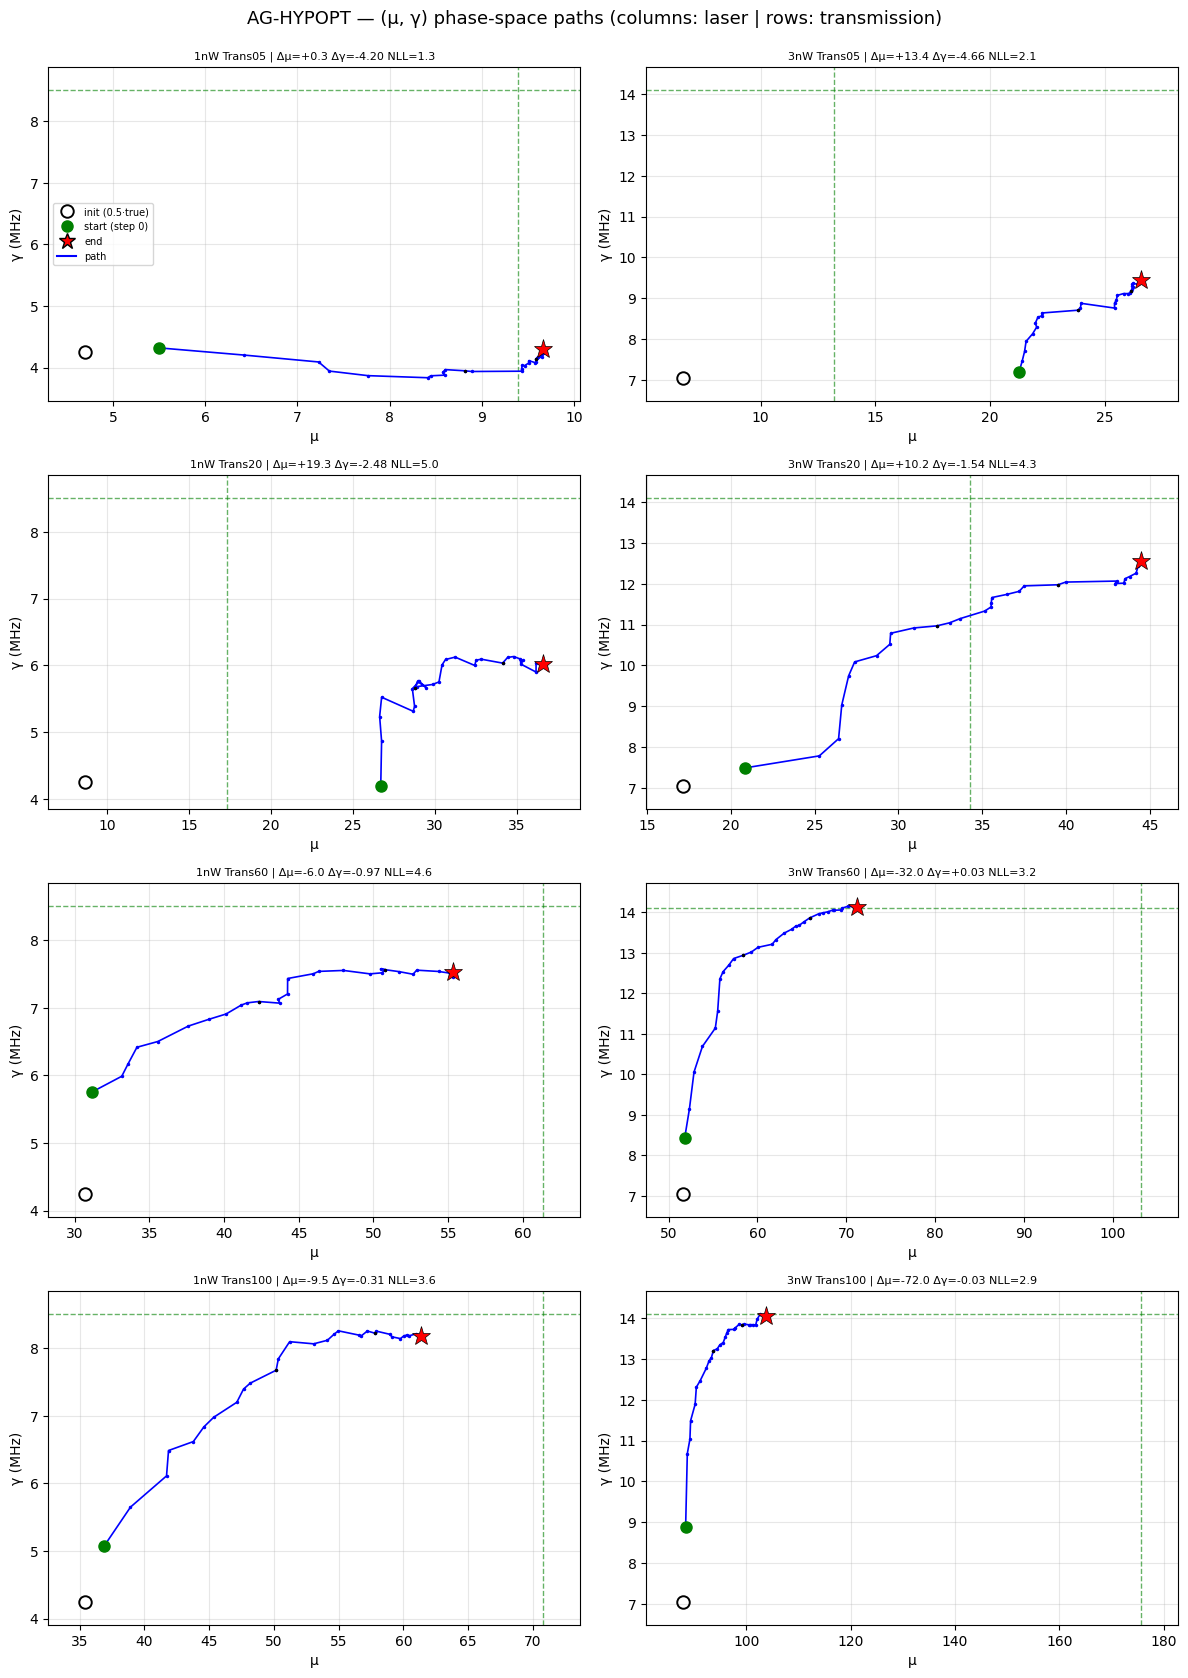

trial finished in 7.9 min
objective = 0.1188 ± 0.0821
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    9.67    +2.9 |     8.50    4.30   -49.4
1nW Trans20       17.32   36.63  +111.5 |     8.50    6.02   -29.2
1nW Trans60       61.37   55.34    -9.8 |     8.50    7.53   -11.4
1nW Trans100       70.82   61.37   -13.3 |     8.50    8.19    -3.7
3nW Trans05       13.20   26.60  +101.4 |    14.10    9.44   -33.0
3nW Trans20       34.28   44.50   +29.8 |    14.10   12.56   -10.9
3nW Trans60      103.20   71.18   -31.0 |    14.10   14.13    +0.2
3nW Trans100      175.71  103.70   -41.0 |    14.10   14.07    -0.2

weighted objective (T-graded, cap=1.0) = 0.1188 | diverged cells: 0
μ: RMSE 29.564 (rel 57.6%, bias -9.539) | γ: RMSE 2.472 (rel 24.1%, bias -1.770)


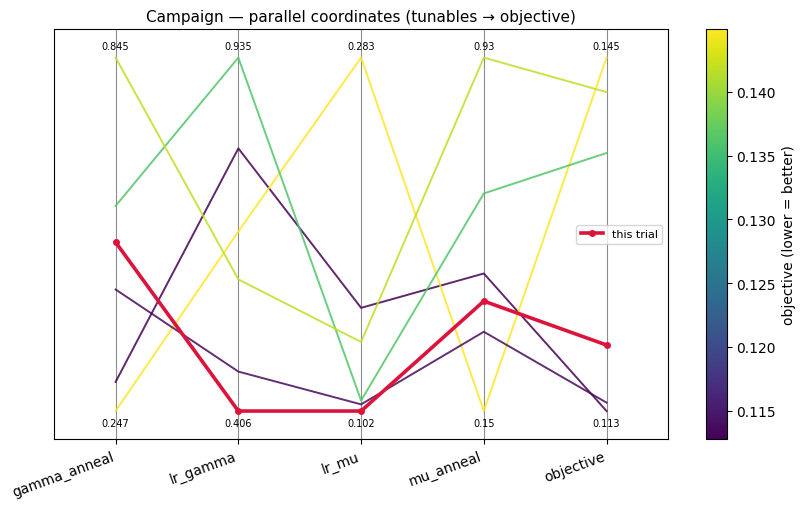

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 06 ran the highest-EI candidate (candidate 1, ei=3.71): `lr_mu=0.1022`, `mu_anneal=0.3925` (effective mu travel 0.082), `lr_gamma=0.4058`, `gamma_anneal=0.5330`. It completed in 7.9 min with objective **0.1188 +/- 0.0821** and **0 diverged cells**. Ranking: trial_01 0.1127 < trial_05 0.1135 < **trial_06 0.1188** < trial_03 0.1362 < trial_04 0.1418 < trial_02 0.1449.

Aggregate accuracy: **mu rel-RMSE 57.6%** (RMSE 29.56, bias -9.54) — in line with trials 03/05 (55-60%); **gamma rel-RMSE 24.1%** (RMSE 2.47, bias -1.77), again finite on every cell.

Per-cell relative errors:
- **mu:** 1nW T05 +2.9%, T20 +111.5%, T60 -9.8%, T100 -13.3% | 3nW T05 +101.4%, T20 +29.8%, T60 -31.0%, T100 -41.0%.
- **gamma:** 1nW T05 -49.4%, T20 -29.2%, T60 -11.4%, T100 -3.7% | 3nW T05 -33.0%, T20 -10.9%, T60 +0.2%, T100 -0.2%.

The EI-guided proposal did what the model expected — it landed just next to trial_05 (travel 0.082 vs 0.088) and reproduced its behaviour almost exactly: 0 diverged cells, good mu accuracy, gamma accurate at high T and under-recovered at low T. It did **not** beat the two best runs: pushing mu travel a little below trial_05's made the mid-T overshoot marginally worse (1nW T20 +111.5%, 3nW T05 +101.4% vs trial_05's +116.5% / +90.4%) without improving the high-T undershoot (3nW T60 -31.0%, T100 -41.0% vs -31.2% / -40.8%), so the objective drifted up by ~0.005. The three best configurations (trials 01, 05, 06) now form a tight cluster at travel 0.082-0.120, all divergence-free, with trial_05 the best trade-off among them.

**Summary:** Trial 06 (lr_mu=0.1022, mu_anneal=0.3925, lr_gamma=0.4058, gamma_anneal=0.5330): objective 0.1188 +/- 0.0821 with 0 diverged cells; the highest-EI proposal refined the good region (mu travel 0.082, gamma finite on all cells) but did not beat trial_01/trial_05, with mu rel-RMSE 57.6% and the high-T undershoot unchanged.
**Key insight:** The expected-improvement model picked a point right beside trial_05 and reproduced its clean behaviour, but a further travel reduction to 0.082 bought nothing — the local optimum for the objective at fixed gamma settings sits at trial_05's small-but-not-minimal mu travel (0.088).

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** Trials 05 and 06 (both divergence-free, both good mu) are near-duplicates in behaviour, which suggests the remaining objective is dominated by two stubborn, hyperparameter-insensitive features: a large high-T mu undershoot (3nW T60/T100 around -31% / -41% in every low-travel run) and a low-T gamma under-recovery (T05/T20 around -30% to -50%). No global schedule knob has moved either much. That is the standing motivation for the structural levers already noted (n_target-adaptive mu step; per-experiment gamma LR); recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 06 (lr_mu=0.1022, mu_anneal=0.3925, lr_gamma=0.4058, gamma_anneal=0.5330): objective 0.1188 +/- 0.0821 with 0 diverged cells; the highest-EI proposal refined the good region (mu travel 0.082, gamma finite on all cells) but did not beat trial_01/trial_05, with mu rel-RMSE 57.6% and the high-T undershoot unchanged"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The expected-improvement model picked a point right beside trial_05 and reproduced its clean behaviour, but a further travel reduction to 0.082 bought nothing - the local optimum for the objective at fixed gamma settings sits at trial_05's small-but-not-minimal mu travel (0.088)"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_06 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_07.ipynb. Open it and follow its cells from the top.
